In [1]:
!curl -L -o /content/car-object-detection.zip https://www.kaggle.com/api/v1/datasets/download/sshikamaru/car-object-detection

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  112M  100  112M    0     0  80.6M      0  0:00:01  0:00:01 --:--:--  270M


In [2]:
!unzip -q /content/car-object-detection.zip -d /content/car-object-detection

In [3]:
from pathlib import Path
import random
import shutil


def create_yolo_dataset_structure(
    training_images_dir: str,
    output_dir: str,
    train_ratio: float = 0.8,
    seed: int = 42,
):
    """
    Split images into train/val folders for YOLO.

    Parameters
    ----------
    training_images_dir : str
        Folder containing all training images.

    output_dir : str
        Root output directory.

    train_ratio : float
        Fraction of images used for training.

    seed : int
        Random seed.
    """

    training_images_dir = Path(training_images_dir)
    output_dir = Path(output_dir)

    train_img_dir = output_dir / "images" / "train"
    val_img_dir = output_dir / "images" / "val"

    train_label_dir = output_dir / "labels" / "train"
    val_label_dir = output_dir / "labels" / "val"

    for d in [
        train_img_dir,
        val_img_dir,
        train_label_dir,
        val_label_dir,
    ]:
        d.mkdir(parents=True, exist_ok=True)

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

    images = [
        img
        for img in training_images_dir.iterdir()
        if img.suffix.lower() in image_extensions
    ]

    random.seed(seed)
    random.shuffle(images)

    split_idx = int(len(images) * train_ratio)

    train_images = images[:split_idx]
    val_images = images[split_idx:]

    # Copy images
    for img in train_images:
        shutil.copy2(img, train_img_dir / img.name)

    for img in val_images:
        shutil.copy2(img, val_img_dir / img.name)

    print(f"Training images : {len(train_images)}")
    print(f"Validation images: {len(val_images)}")

    return (
        [img.name for img in train_images],
        [img.name for img in val_images],
    )

In [4]:
train_files, val_files = create_yolo_dataset_structure(
    training_images_dir="/content/car-object-detection/data/training_images",
    output_dir="dataset",
    train_ratio=0.8,
)

Training images : 800
Validation images: 201


In [5]:
from pathlib import Path
import pandas as pd
from PIL import Image


def convert_csv_to_yolo(
    csv_file: str,
    images_dir: str,
    labels_dir: str,
    image_filenames: list[str],
    class_mapping: dict,
):
    """
    Convert bounding box CSV annotations into YOLO txt files.

    Parameters
    ----------
    csv_file : str
        Path to annotation CSV.

    images_dir : str
        Directory containing images.

    labels_dir : str
        Output directory for YOLO labels.

    image_filenames : list[str]
        Images to convert (train or val split).

    class_mapping : dict
        Example:
            {
                "cat": 0,
                "dog": 1
            }
    """

    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    labels_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(csv_file)

    # Remove extension if CSV stores image ids only
    df["image_id"] = df["image"].astype(str)

    # allowed = {
    #     Path(name).stem
    #     for name in image_filenames
    # }
    # print(allowed)
    # print(df["image_id"])

    df = df[df["image_id"].isin(image_filenames)]
    # print(len(df))

    grouped = df.groupby("image_id")
    print(len(grouped))
    # i = 0

    for image_name, group in grouped:
      # print(i)
      # i = i + 1

      image_path = images_dir / image_name

      if not image_path.exists():
          print(f"Image not found: {image_path}")
          continue

      width, height = Image.open(image_path).size

      txt_path = labels_dir / f"{Path(image_name).stem}.txt"

      with open(txt_path, "w") as f:

          for _, row in group.iterrows():

              xmin = row["xmin"]
              ymin = row["ymin"]
              xmax = row["xmax"]
              ymax = row["ymax"]

              # cls = class_mapping[row["class"]]
              cls = 0

              x_center = ((xmin + xmax) / 2) / width
              y_center = ((ymin + ymax) / 2) / height

              box_width = (xmax - xmin) / width
              box_height = (ymax - ymin) / height

              f.write(
                  f"{cls} "
                  f"{x_center:.6f} "
                  f"{y_center:.6f} "
                  f"{box_width:.6f} "
                  f"{box_height:.6f}\n"
              )

In [6]:
csv_file = "/content/car-object-detection/data/train_solution_bounding_boxes (1).csv"

In [7]:
import pandas as pd

df = pd.read_csv(csv_file)
print(df.columns)
print(df.head())

Index(['image', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')
             image        xmin        ymin        xmax        ymax
0   vid_4_1000.jpg  281.259045  187.035071  327.727931  223.225547
1  vid_4_10000.jpg   15.163531  187.035071  120.329957  236.430180
2  vid_4_10040.jpg  239.192475  176.764801  361.968162  236.430180
3  vid_4_10020.jpg  496.483358  172.363256  630.020260  231.539575
4  vid_4_10060.jpg   16.630970  186.546010  132.558611  238.386422


In [8]:
convert_csv_to_yolo(
    csv_file=csv_file,
    images_dir="/content/car-object-detection/data/training_images",
    labels_dir="/content/dataset/labels/train",
    image_filenames=train_files,
    class_mapping={
        "car": 0
    },
)

convert_csv_to_yolo(
    csv_file=csv_file,
    images_dir="/content/dataset/images/val",
    labels_dir="/content/dataset/labels/val",
    image_filenames=val_files,
    class_mapping={
        "car": 0
    },
)

276
79


In [9]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00


In [10]:
import yaml

data = {
    'path': '/content/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'car'
    }
}

# Write the data to data.yaml
with open('/content/dataset/data.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False, sort_keys=False)


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d97e41507d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [12]:
results = model.val(
    data="dataset/data.yaml",
    plots=True,
    save_json=True
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2551.3±708.5 MB/s, size: 103.3 KB)
val: Scanning /content/dataset/labels/val.cache... 79 images, 122 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 42.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.0it/s 4.3s
                   all        201        129      0.953      0.984      0.984      0.654
Speed: 4.2ms preprocess, 5.3ms inference, 0.0ms loss, 2.7ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val


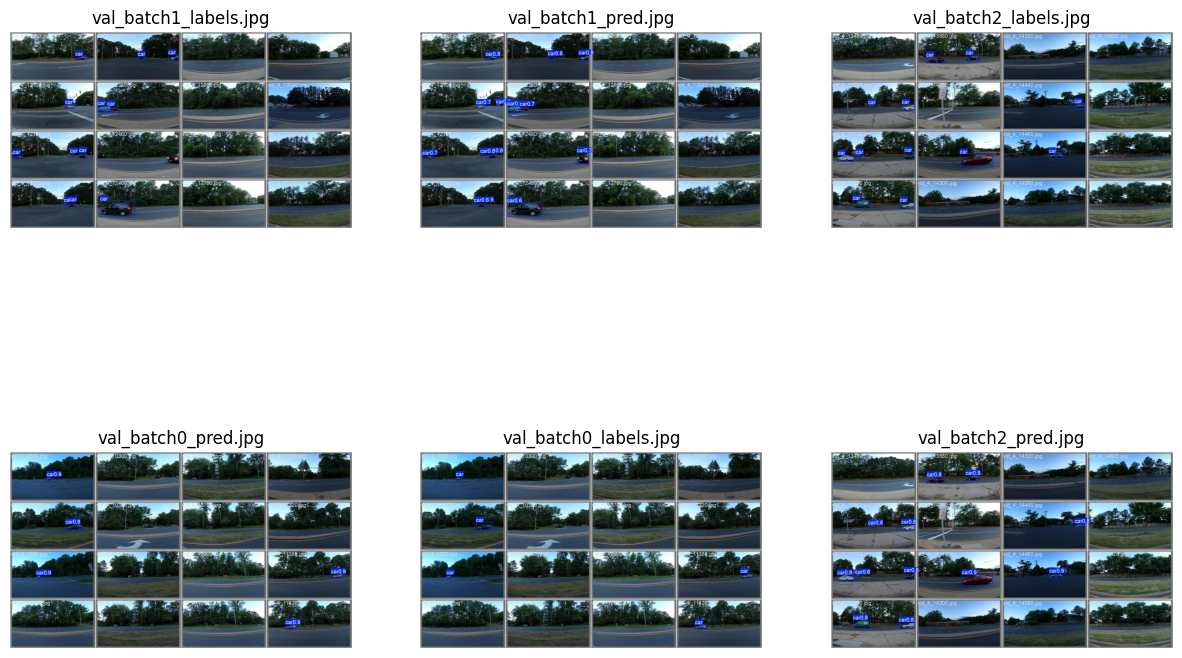

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import random

pred_dir = Path("/content/runs/detect/val")

images = list(pred_dir.glob("*.jpg"))
random.shuffle(images)

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(images[:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(Image.open(img_path))
    plt.axis("off")
    plt.title(img_path.name)

# plt.tight_layout()
plt.show()